# Phân tích Outliers và Độ biến thiên (Age)
Mục tiêu:
* Kiểm tra chất lượng dữ liệu và tính nhất quán.
* Sử dụng Boxplot để quan sát sự phân tán của độ tuổi.
* Xác định các giá trị ngoại lai (Outliers) bằng phương pháp IQR (Interquartile Range).
* So sánh đặc điểm độ tuổi giữa nhóm bệnh nhân bị tiểu đường và nhóm bình thường.
* Khảo sát mối tương quan giữa Age và Glucose.

In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

current_path = Path().resolve()
repo_root = current_path
for parent in current_path.parents:
    if parent.name == "Nhom01_SGU26_ML":
        repo_root = parent
        break

data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"
column_names = ["pregnancies", "glucose", "blood_pressure", "skin_thickness", "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"]
df = pd.read_csv(data_path, header=None, names=column_names)

df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:

# Kiểm tra dữ liệu
if 'df' not in locals():
    column_names = ["pregnancies", "glucose", "blood_pressure", "skin_thickness", "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"]
    current_path = Path().resolve()
    repo_root = current_path
    for parent in current_path.parents:
        if parent.name == "Nhom01_SGU26_ML":
            repo_root = parent
            break
    data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"
    df = pd.read_csv(data_path, header=None, names=column_names)

### 1. Dữ liệu gốc (Kiểm tra tính nhất quán sinh lý)
Về mặt sinh lý, tuổi không thể bằng 0. Chúng ta cần xác nhận cột Age hoàn toàn hợp lệ trước khi phân tích sâu.

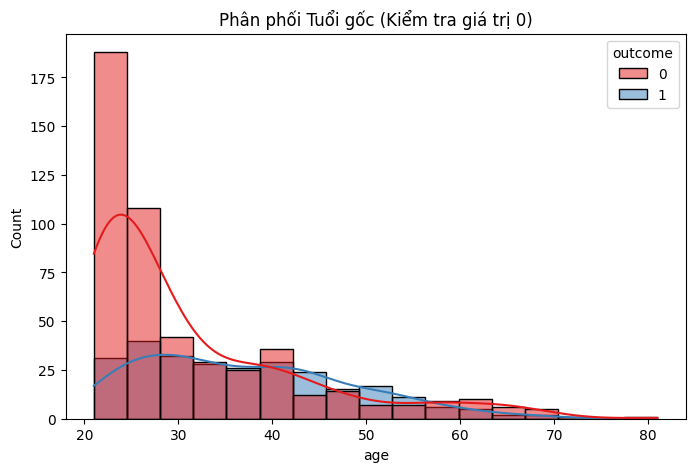

Số lượng mẫu có Age = 0: 0
=> Nhận xét: Cột Age không có giá trị thiếu, dữ liệu đảm bảo tính nhất quán sinh lý.


In [31]:
fig_raw, ax_raw = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="outcome", kde=True, ax=ax_raw, palette="Set1")
ax_raw.set_title("Phân phối Tuổi gốc (Kiểm tra giá trị 0)")
plt.show()

zero_count = (df['age'] == 0).sum()
print(f"Số lượng mẫu có Age = 0: {zero_count}")
print("=> Nhận xét: Cột Age không có giá trị thiếu, dữ liệu đảm bảo tính nhất quán sinh lý.")

### 2. Phân tích giá trị ngoại lai (Outliers Detection)
Chúng ta sử dụng phương pháp IQR để xác định những bệnh nhân có độ tuổi cao bất thường, nhằm tránh làm nhiễu mô hình dự báo.

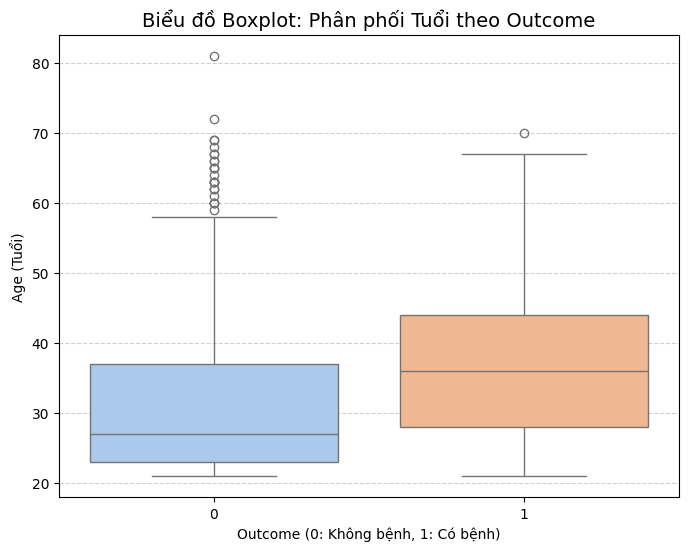

In [33]:
# VẼ BOXPLOT 
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="outcome", y="age", hue="outcome", palette="pastel", legend=False)

plt.title("Biểu đồ Boxplot: Phân phối Tuổi theo Outcome", fontsize=14)
plt.xlabel("Outcome (0: Không bệnh, 1: Có bệnh)")
plt.ylabel("Age (Tuổi)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [40]:
# Tính Toán OUTLIERS
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

In [41]:
print(f"--- Kết quả phân tích ---")
print(f"Ngưỡng ngoại lai trên: {upper_limit}")
outliers = df[df['age'] > upper_limit]
print(f"Số lượng Outliers phát hiện: {len(outliers)}")

--- Kết quả phân tích ---
Ngưỡng ngoại lai trên: 66.5
Số lượng Outliers phát hiện: 9


**Nhận xét:**
1. **Về phân phối:** Nhóm `Outcome = 1` có dải tuổi (Box) nằm cao hơn so với nhóm `Outcome = 0`, cho thấy độ tuổi trung bình của người mắc bệnh cao hơn.
2. **Về Outliers:** Phát hiện một số điểm dữ liệu nằm trên ngưỡng `{upper_limit}`. Đây là những bệnh nhân lớn tuổi đặc biệt trong tập dữ liệu. Việc xác định Outliers giúp chúng ta cân nhắc việc có nên loại bỏ các giá trị này khi huấn luyện mô hình hay không.